# Supervised - Medical Cost- Random Forest

In [ ]:
# Import Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Data Ingestion

In [ ]:
# Load Dataset
df = pd.read_csv("insurance.csv")

In [ ]:
# This displays the top 5 rows of the data
# We usually do this to check data structure and if data is being loaded properly
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Exploratory Data Analysis

In [ ]:
# Exploratory Data Analysis (EDA)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [ ]:
# Display data description
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


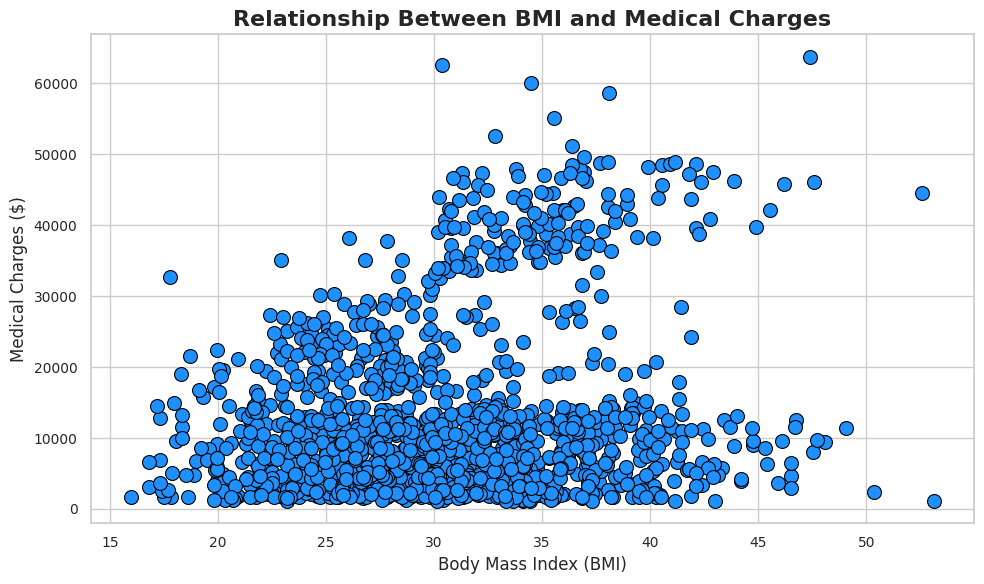

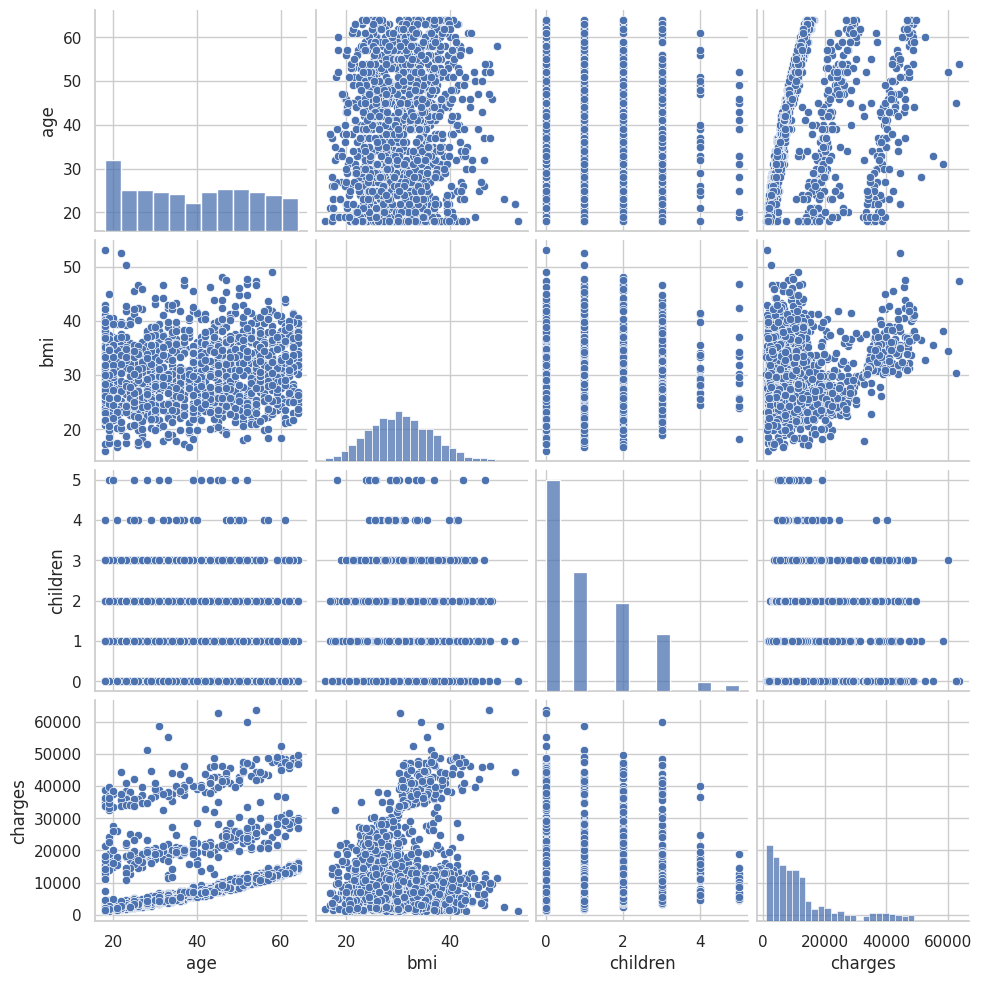

In [ ]:
# Set seaborn theme
sns.set_theme(style="whitegrid")

# Scatter Plot: Relationship Between BMI and Medical Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['bmi'], y=df['charges'], color="dodgerblue", s=100, edgecolor="black")

# Add titles and labels
plt.title('Relationship Between BMI and Medical Charges', fontsize=16, fontweight='bold')
plt.xlabel('Body Mass Index (BMI)', fontsize=12)
plt.ylabel('Medical Charges ($)', fontsize=12)

# Enhance plot aesthetics
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

# Pairplot untuk melihat hubungan antar variabel
sns.pairplot(df)
plt.show()

### Data Preparation
1. Check Duplicated Data
2. Check Missing Value Handling
3. Encoding categorical : change string (categorical) into numerical -> in this dataset, there is no categorical column.

In [ ]:
df = data.copy()

In [ ]:
#Check Duplicated Data
print("Data Sebelum Pemeriksaan Duplikat:")
print(df.shape)

Data Sebelum Pemeriksaan Duplikat:
(1338, 7)


In [ ]:
duplicated_rows = df[df.duplicated(keep=False)]
duplicated_rows

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df = df.drop_duplicates()

In [ ]:
print("\nData Setelah Pemeriksaan Duplikat:")
print(df.shape)


Data Setelah Pemeriksaan Duplikat:
(1337, 7)


In [ ]:
#Check missing value
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# One-Hot Encoding untuk fitur kategorikal (sex, smoker, region)
df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

In [ ]:
# Feature Scaling untuk fitur numerik (age, bmi, children)
scaler = StandardScaler()
df[['age', 'bmi', 'children']] = scaler.fit_transform(df[['age', 'bmi', 'children']])

### Splitting the data

In [ ]:
X = df.drop(columns=['charges'])  # Fitur (tanpa target)
y = df['charges']  # Target (Medical Cost)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Import machine learning data from scikit learn
from sklearn.model_selection import train_test_split

In [ ]:
# Split the data for train and test
# train : test = 75 : 25 atau 80 : 20 atau 70:30 atau 85:15 , size train > test
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.75,random_state=42)

In [ ]:
X_train.shape

(1002, 8)

In [ ]:
X_test.shape

(335, 8)

In [ ]:
# Reshape because we only have single features.
# This is not needed if our features is 2 or more
X_train_reshape = X_train.values.reshape(-1, 1)
X_test_reshape = X_test.values.reshape(-1, 1)

### Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model_rf = RandomForestRegressor()

In [ ]:
model = RandomForestRegressor(n_estimators=200, max_depth=6,
                              min_samples_split=10, min_samples_leaf=4,
                              random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=6, min_samples_leaf=4, min_samples_split=10,
                      n_estimators=200, random_state=42)

### Evaluasi Model

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

In [ ]:
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [ ]:
print(f"Train MAE: {train_mae:.2f}")
print(f"Train MSE: {train_mse:.2f}")
print(f"Train R² Score: {train_r2:.4f}")

print(f"Test MAE: {test_mae:.2f}")
print(f"Test MSE: {test_mse:.2f}")
print(f"Test R² Score: {test_r2:.4f}")

Train MAE: 2166.69
Train MSE: 15681758.05
Train R² Score: 0.8860
Test MAE: 2447.87
Test MSE: 19040272.98
Test R² Score: 0.8899


##Feature Importance Analysis

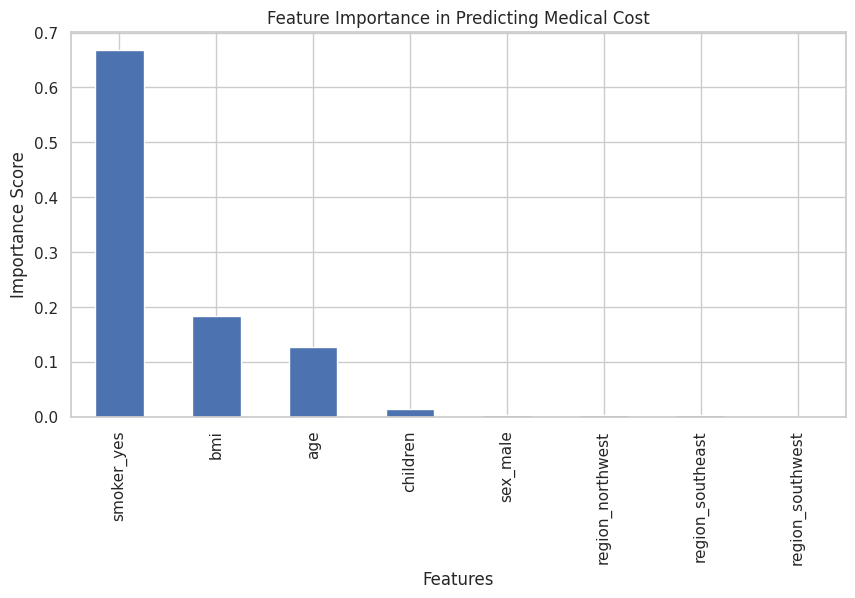

In [ ]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Feature Importance in Predicting Medical Cost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

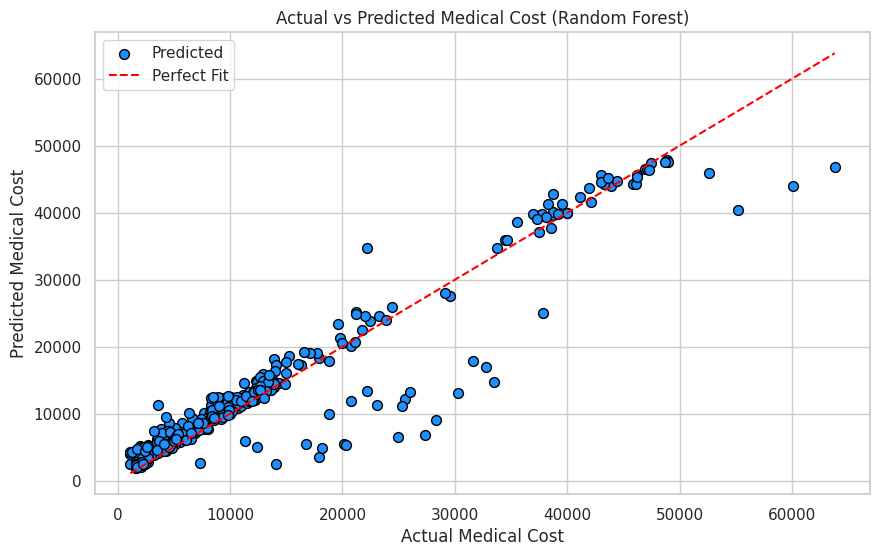

In [ ]:
# 9️⃣ Scatter Plot: Actual vs Predicted (Random Forest)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, color='dodgerblue', s=50, edgecolor='black', label="Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', label="Perfect Fit")
plt.xlabel("Actual Medical Cost")
plt.ylabel("Predicted Medical Cost")
plt.title("Actual vs Predicted Medical Cost (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()